In [1]:
import Kea
from Kea.utils import plotting, funcs
from Kea.simulator import fbm
from Kea.statistics import statistics_base, moments
from Kea.statistics.spectra import strfn_spectra, spectra_base, arevalo_spectra, per_spectra
from Kea.statistics.statfunc import strfn, statfunc_base, statfunc_mpi_naive
from Kea.fitting import fit_base

c = plotting.COLOR_CYCLE_6

import matplotlib as mpl
plotting.modify_rc()
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable

import numpy as np

D = 2
N = 512
L = 5.*np.pi
grid_dims = [N for _ in range(D)]
phys_dims = [L for _ in range(D)]

twopi = 2.*np.pi
dk = twopi/L
dx = L/N

In [2]:
amin, amax = -(D+3.), -1.
NUM = 10
alphas = np.linspace(amax, amin, NUM)
np.random.seed(1234)
fields = []
models = []

BREAK1 = 0 * dk
BREAK2 = 25 * dk

for a in alphas:
    fields.append(fbm.create_fbm(grid_dims, phys_dims, (a,), gfunc='pow_exp', func_kwargs={'breaks': (BREAK1,BREAK2)}))

energies = []
for f in fields:
    energies.append(moments.var(f, lenn=phys_dims))

models = []
Pspecs = []
Aspecs = []
for i, f in enumerate(fields):
    kD, fekD = per_spectra.modal_spectrum(f, phys_dims=phys_dims)
    kmesh = spectra_base.wavenumber_mesh(kD)

    _km, _fekm, width = statistics_base.bin_data(kmesh, fekD,
            bin_func=np.nanmean, min_bin=dk, max_bin=None,
            ignore_nan=False, norm_bin_size=False, bin_loc='true_center',
            cut_excess=True, nan_small=False)
    Pspecs.append((_km, _fekm))

    fekD_model = funcs.pow_exp(kmesh, (alphas[i],), (BREAK1,BREAK2))
    var = np.nansum(fekD_model * (dk/twopi)**D)
    fekD_model = fekD_model / var
    k_model, fek_model, w = statistics_base.bin_data(kmesh, fekD_model,
            bin_func=np.nanmean, min_bin=dk, max_bin=None,
            ignore_nan=False, norm_bin_size=False, bin_loc='true_center',
            cut_excess=True, nan_small=False)
    models.append((k_model, fek_model))

    lags = arevalo_spectra.k_to_discrete_lags(_km, N, L)
    km, fekm = arevalo_spectra.modal_spectrum(f, lenn=phys_dims, lags=lags, mode='wrap')
    Aspecs.append((km, fekm))

/home/m/Documents/science_codes/Kea/Kea/utils/funcs.py:77: RuntimeWarning: divide by zero encountered in reciprocal
  pl = xx**(a1) * np.exp(-(b1/xx)**2) * np.exp(-(xx/b2)**2)
/home/m/Documents/science_codes/Kea/Kea/utils/funcs.py:77: RuntimeWarning: invalid value encountered in true_divide
  pl = xx**(a1) * np.exp(-(b1/xx)**2) * np.exp(-(xx/b2)**2)
/home/m/Documents/science_codes/Kea/Kea/utils/funcs.py:77: RuntimeWarning: divide by zero encountered in power
  pl = xx**(a1) * np.exp(-(b1/xx)**2) * np.exp(-(xx/b2)**2)
/home/m/.local/lib/python3.10/site-packages/scipy/stats/_binned_statistic.py:665: RuntimeWarning: Mean of empty slice
  result[vv, i] = stat_func(np.array(bin_map[i]))
/home/m/Documents/science_codes/Kea/Kea/utils/funcs.py:77: RuntimeWarning: divide by zero encountered in reciprocal
  pl = xx**(a1) * np.exp(-(b1/xx)**2) * np.exp(-(xx/b2)**2)
/home/m/Documents/science_codes/Kea/Kea/utils/funcs.py:77: RuntimeWarning: invalid value encountered in true_divide
  pl = xx**(a1) *

In [3]:
cols = plt.get_cmap('Greys')(np.linspace(0.25, 1., NUM))
cols2 = plt.cm.Blues(np.linspace(0.25, 1., NUM))
cols3 = plt.cm.Greens(np.linspace(0.25, 1., NUM))
upper_cmap = mpl.colors.LinearSegmentedColormap.from_list('Upper', cols2)

(0.1, 1000000.0)

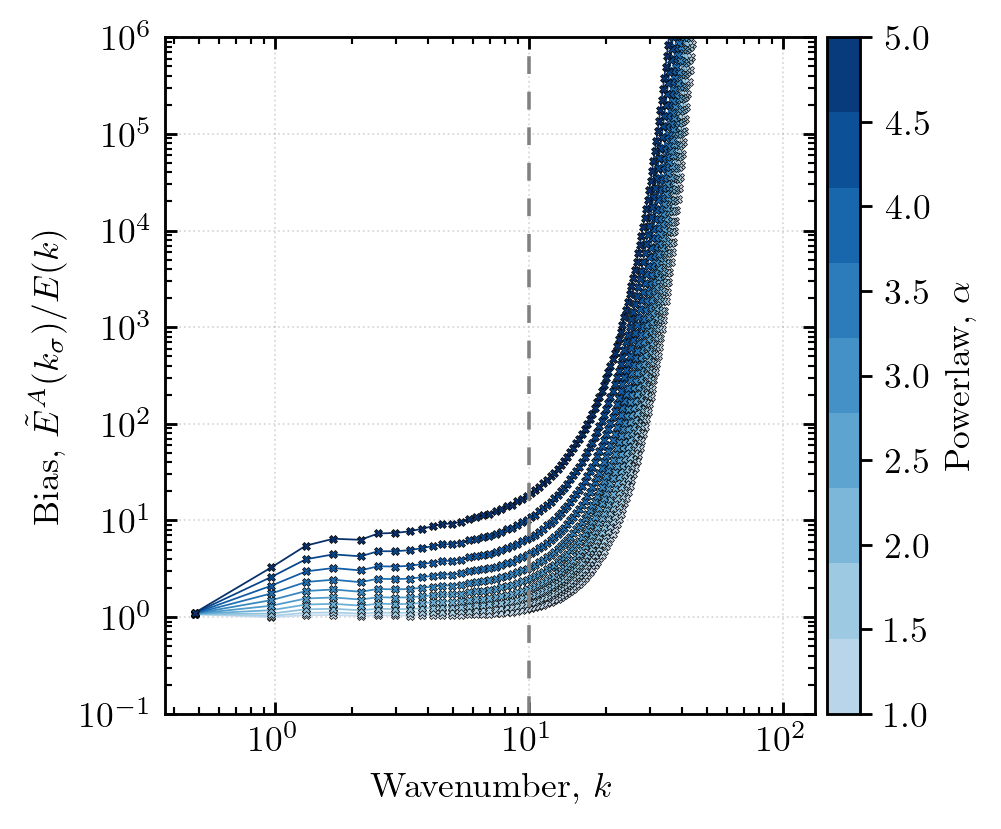

In [4]:
fig, ax = plt.subplots(1, 1, figsize=(3.5, 3.5), dpi=256)

bias = []

for i in range(len(Aspecs)):
    pk, pfek = Pspecs[i]
    ak, afek = Aspecs[i]
    ax.plot(ak, afek / pfek, color=cols2[i], linewidth=0.5, marker='X', markersize=2.5, zorder=2, markeredgewidth=0.2, markeredgecolor='black')
    bias.append((ak, afek/pfek))

ax.set_yscale('log')
ax.set_xscale('log')

ax.axvline(BREAK2, linestyle=(0,(5,5)), linewidth=1., color='gray')

ax.yaxis.set_ticks_position('both')
ax.xaxis.set_ticks_position('both')
ax.tick_params(axis='y', direction='in')
ax.tick_params(axis='y', direction='in', which='minor')
ax.tick_params(axis='x', direction='in')
ax.tick_params(axis='x', direction='in', which='minor')
ax.grid(linestyle=':', alpha=0.3, linewidth=0.5, color='gray')

divider = make_axes_locatable(ax)
cax = divider.append_axes('right', size='5%', pad=0.05)

sm = plt.cm.ScalarMappable(cmap=upper_cmap, norm=mpl.colors.Normalize(-amax, -amin))
cbar = fig.colorbar(sm, cax=cax, boundaries=np.linspace(-amax, -amin, NUM), ticks=np.arange(-amax, -amin+1., 0.5))

cbar.ax.set_ylabel('Powerlaw, $\\alpha$')

ax.set_ylabel('Bias, $\\tilde{E}^A(k_\sigma)/E(k)$')
ax.set_xlabel('Wavenumber, $k$')

ax.set_ylim((1e-1, 1e6))

In [13]:
print(alphas)

[-1.         -1.44444444 -1.88888889 -2.33333333 -2.77777778 -3.22222222
 -3.66666667 -4.11111111 -4.55555556 -5.        ]


(0.01, 100.0)

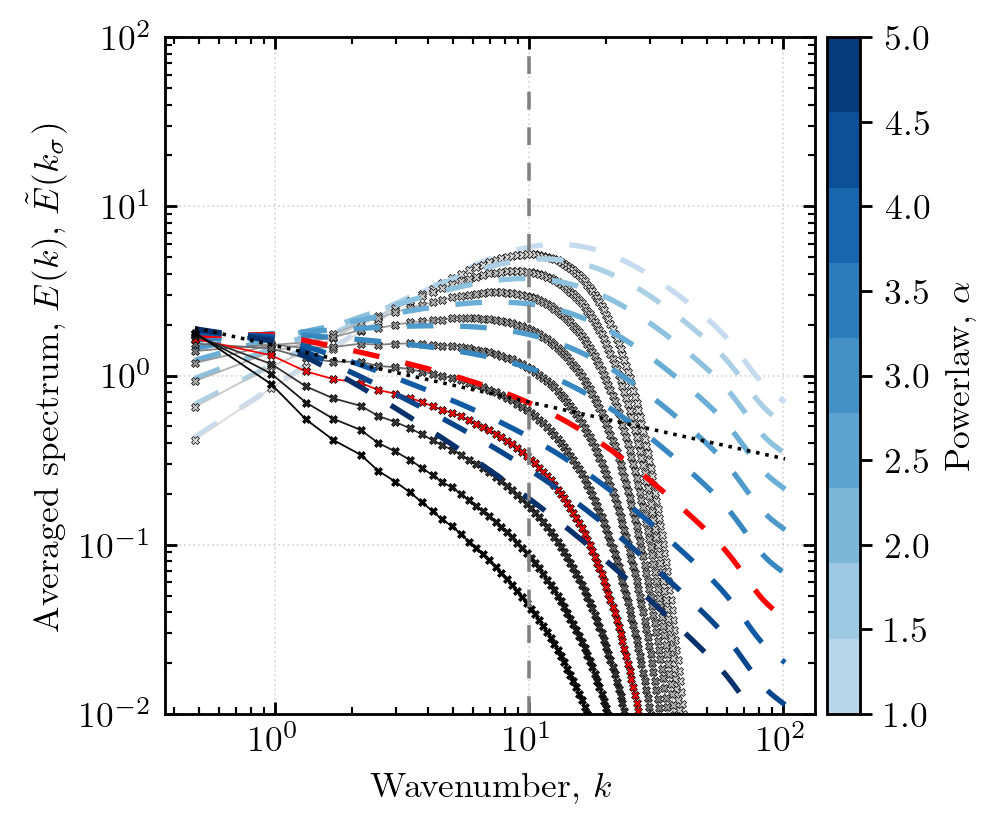

In [14]:
fig, ax = plt.subplots(1, 1, figsize=(3.5, 3.5), dpi=256)

bias = []

for i in range(len(Aspecs)):
    pk, pfek = Pspecs[i]
    ak, afek = Aspecs[i]
    if i == 6:
        ax.loglog(ak, np.sqrt(ak * ak**2 * afek), color='red', linestyle=(0, (5,5)))
        ax.loglog(pk, np.sqrt(pk * pk**2 * pfek), color='red', linewidth=0.5, marker='X', markersize=2.5, zorder=2, markeredgewidth=0.2, markeredgecolor='black')
    else:
        ax.loglog(ak, np.sqrt(ak * ak**2 * afek), color=cols2[i], linestyle=(0, (5,5)))
        ax.loglog(pk, np.sqrt(pk * pk**2 * pfek), color=cols[i], linewidth=0.5, marker='X', markersize=2.5, zorder=2, markeredgewidth=0.2, markeredgecolor='black')
    #bias.append((ak, afek/pfek))

ax.axvline(BREAK2, linestyle=(0,(5,5)), linewidth=1., color='gray')

ax.yaxis.set_ticks_position('both')
ax.xaxis.set_ticks_position('both')
ax.tick_params(axis='y', direction='in')
ax.tick_params(axis='y', direction='in', which='minor')
ax.tick_params(axis='x', direction='in')
ax.tick_params(axis='x', direction='in', which='minor')
ax.grid(linestyle=':', alpha=0.3, linewidth=0.5, color='gray')

divider = make_axes_locatable(ax)
cax = divider.append_axes('right', size='5%', pad=0.05)

sm = plt.cm.ScalarMappable(cmap=upper_cmap, norm=mpl.colors.Normalize(-amax, -amin))
cbar = fig.colorbar(sm, cax=cax, boundaries=np.linspace(-amax, -amin, NUM), ticks=np.arange(-amax, -amin+1., 0.5))

cbar.ax.set_ylabel('Powerlaw, $\\alpha$')

ax.set_ylabel('Averaged spectrum, $E(k)$, $\\tilde{E}(k_\sigma)$')
ax.set_xlabel('Wavenumber, $k$')

ax.loglog(ak, 1.5*ak**(-1./3.), linewidth=1., color='black', linestyle=':')

ax.set_ylim((1e-2, 1e2))

/tmp/ipykernel_14298/1007046113.py:3: RuntimeWarning: divide by zero encountered in power
  f = np.exp(-2.*(k/b)**2) * (k/b)**(-11./3.)
/tmp/ipykernel_14298/1007046113.py:5: RuntimeWarning: divide by zero encountered in power
  plt.loglog(k, 1e5*k**(-11./3.))


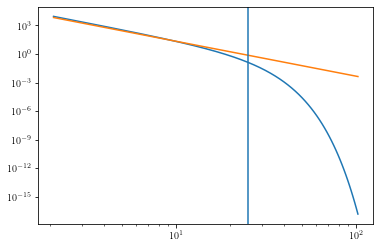

In [6]:
k = np.linspace(0, np.pi*N/L)
b = 25
f = np.exp(-2.*(k/b)**2) * (k/b)**(-11./3.)
plt.loglog(k, f)
plt.loglog(k, 1e5*k**(-11./3.))
plt.axvline(b)